# Extended Data Fig. 28 - Practical 2D sampling in VCP and AppNL-G-F models: variability and recall

Two independent neurodegeneration models (VCP: VCP-WT vs VCP-K524A, n=3 each; AppNL-G-F: WT vs App, n=4 each) are evaluated under Protocol 1 (random coronal sections) and Protocol 2 (uniform-interval / stereology-style), using optically derived sections from the 3D whole-brain reference.

- ED28b: Normalized Average CV2D (3D CV3D = 1.0) vs sampling density (VCP).
- ED28 recall: Average 2D Recall of neuronal-decrease regions vs sampling density. At practical upper-range settings the recall of neuronal decrease stays low: App = 0.20 (Protocol 1, 5 sections) / 0.39 (Protocol 2, 150 um); VCP = 0.31 (Protocol 1) / 0.43 (Protocol 2).

> Figures and the printed recall values are preserved from the original run; Japanese stripped; verbose logs removed.

## Input files

| File | Content |
|---|---|
| `..._raw_value_regions_glm_ver_<tag>_random_slice_<n>_trial_<t>.csv` | Protocol-1 per-trial 2D-sampled region sets (App & VCP) |
| `WT_9m_vs_APP_9m_raw_value_regions_<tag>.csv`, `VCP_WT_vs_mut_raw_value_regions_<tag>.csv` | full-3D ground-truth region sets |
| `Combined_recall_vs_slice_number_data_*.csv`, `Recall_vs_SamplingSpan_Stereology_Summary*.csv` | recall summaries (Protocol 1 / 2) |
| `normalized_cv_results_*VCP*.csv` | normalized CV table (VCP) |

## ED28b - Normalized CV2D vs sampling density (VCP): Protocol 1 then Protocol 2

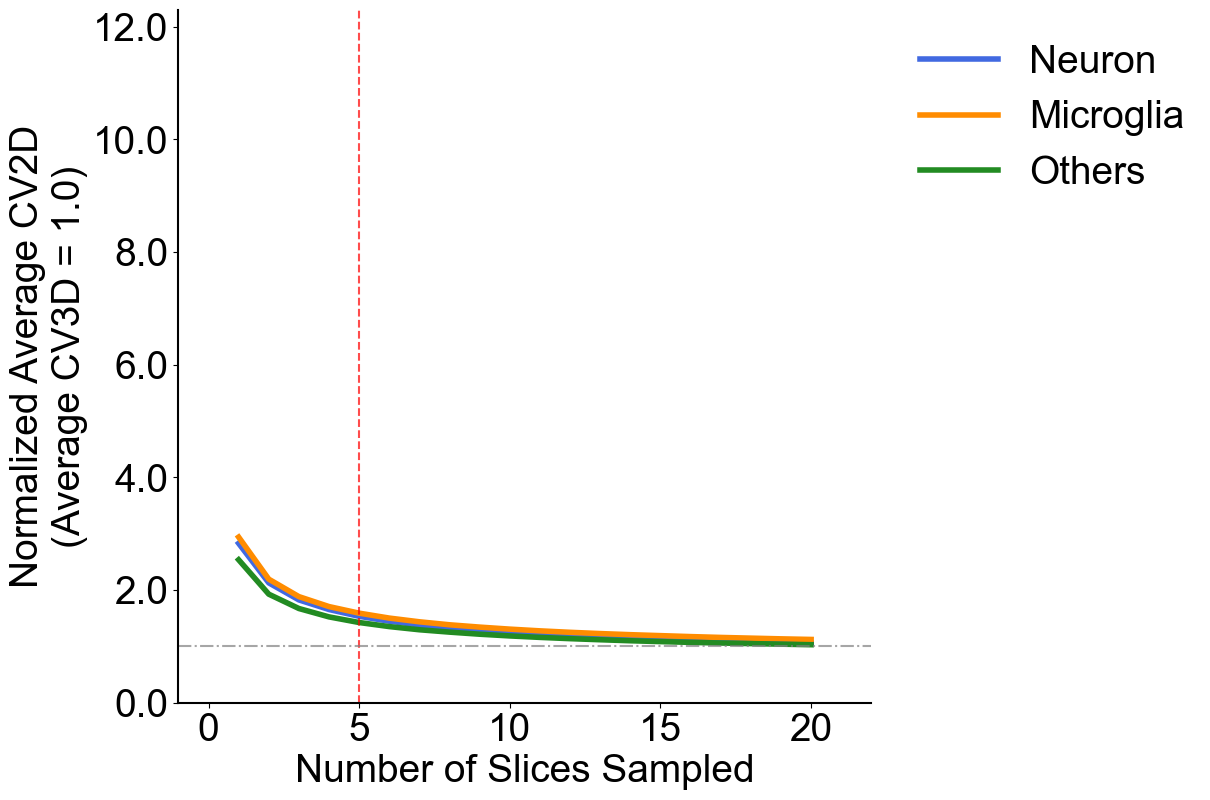

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as mticker

#
GROUP_TO_ANALYZE = "newVCP_mut_2m" #  

cell_types_to_plot = {
    "NeuN":   {"file_tag": "neun",   "color": "royalblue",   "label": "Neuron"},
    "Iba1":   {"file_tag": "iba1",   "color": "darkorange",  "label": "Microglia"},
    "Others": {"file_tag": "others", "color": "forestgreen", "label": "Others"}
}

#
output_base_path = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/"
output_pdf_path = os.path.join(output_base_path, f"Rescaled_Raw_cv_2D_vs_slice_count_{GROUP_TO_ANALYZE}_filtered.pdf")
#
output_csv_path = os.path.join(output_base_path, f"cv_analysis_vs_slice_count_{GROUP_TO_ANALYZE}_summary.csv")


#
if __name__ == "__main__":
    
    #
    all_results_df = pd.DataFrame()

    #
    plt.style.use('default')
    matplotlib.rcParams['pdf.use14corefonts'] = True
    matplotlib.rcParams['font.family'] = 'Arial'
    matplotlib.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(9, 9))

    #
    for cell_type, params in cell_types_to_plot.items():
        filename = os.path.join(output_base_path, f"cv_analysis_vs_slice_count_{GROUP_TO_ANALYZE}_{params['file_tag']}.csv")
        try:
            df = pd.read_csv(filename, index_col='region_id')
            
            #
            df_raw_cv = df.filter(like='_raw_cv')
            s_3d_cv = df['3d_cv']
            mean_3d_cv = s_3d_cv.mean()
            df_scaled_cv = df_raw_cv / mean_3d_cv
            
            df_scaled_cv.columns = df_scaled_cv.columns.str.replace('slices_', '').str.replace('_raw_cv', '').astype(int)
            
            mean_scaled_cv = df_scaled_cv.mean(axis=0)
            std_scaled_cv = df_scaled_cv.std(axis=0)

            #
            mean_to_plot = mean_scaled_cv.loc[1:20]
            std_to_plot = std_scaled_cv.loc[1:20]
            
            #
            df_temp_results = pd.DataFrame({
                'Number of Slices': mean_to_plot.index,
                'Mean Scaled CV': mean_to_plot.values,
                'Std Scaled CV': std_to_plot.values
            })
            df_temp_results['Cell Type'] = params['label']
            
            #
            all_results_df = pd.concat([all_results_df, df_temp_results], ignore_index=True)


            #
            ax.plot(mean_to_plot.index, mean_to_plot.values,
                    linewidth=4,
                    color=params['color'],
                    label=params['label'])
            
            ax.fill_between(
                std_to_plot.index,
                (mean_to_plot - std_to_plot),
                (mean_to_plot + std_to_plot),
                color=params['color'],
                alpha=0.0
            )

        except (FileNotFoundError, KeyError) as e:
            print(f"WARNING: Could not process {filename}. Reason: {e}")
            continue

    #
    ax.set_xlabel('Number of Slices Sampled', fontsize=28)
    ax.set_ylabel('Normalized Average CV2D\n(Average CV3D = 1.0)', fontsize=28)
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.axvline(x=5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axhline(y=1.0, color='gray', linestyle='dashdot', linewidth=1.5, alpha=0.7)
    ax.set_ylim(bottom=0, top=12.3)
    ax.set_xlim(left=-1, right=22)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    formatter = mticker.FormatStrFormatter('%.1f')
    ax.yaxis.set_major_formatter(formatter)
    x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    ax.set_aspect(aspect=x_range/y_range, adjustable='box')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=28, frameon=False)

    #
    #
    plt.savefig(output_pdf_path, transparent=True, dpi=300, bbox_inches='tight', pad_inches=0.1)
    print(f"\nPlot saved to: {output_pdf_path}")
    
    #
    all_results_df.to_csv(output_csv_path, index=False)
    print(f"Results summary saved to: {output_csv_path}")

    plt.show()

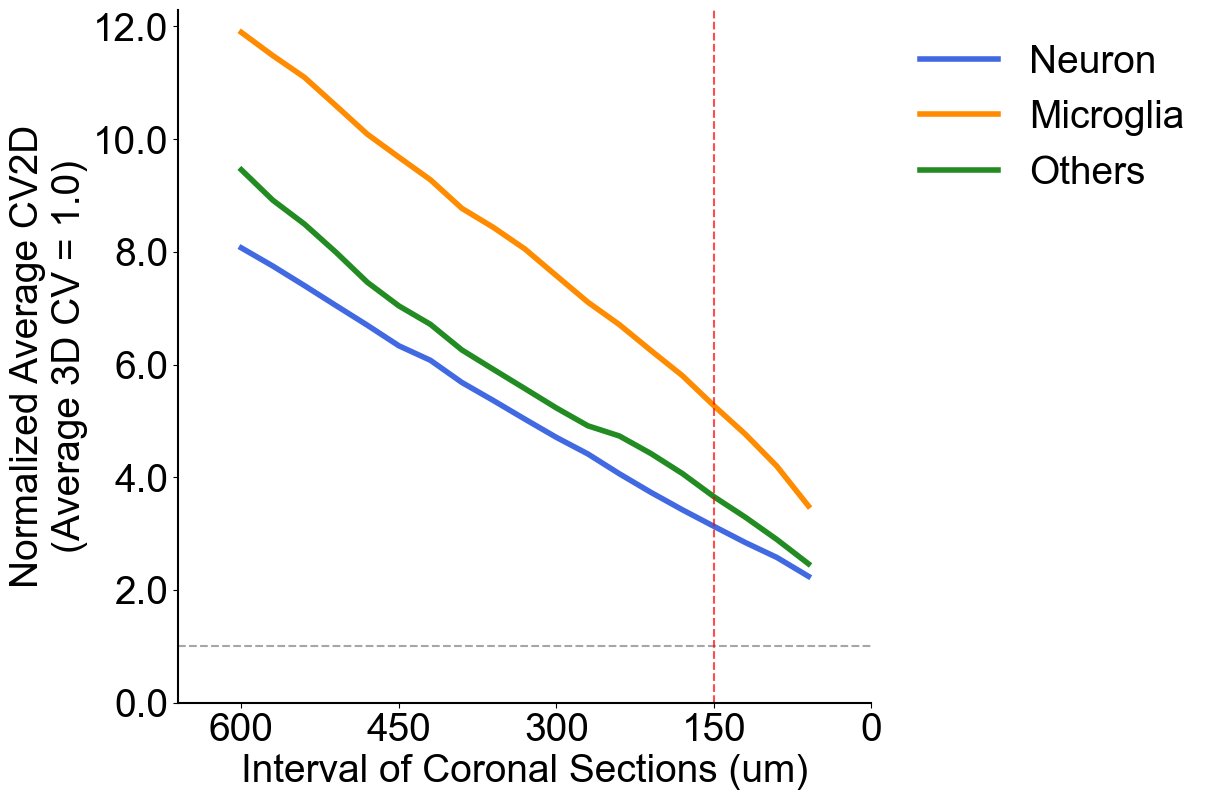

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib

#
GROUP_TO_ANALYZE = "newVCP_mut_2m"

#
CELL_TYPE_MAPPING = {
    "neun": {"column": "NeuN+ density (/mm3)", "color": "royalblue", "label": "Neuron"},
    "iba1": {"column": "Iba1+ density (/mm3)", "color": "darkorange", "label": "Microglia"},
    "others": {"column": "Others density (/mm3)", "color": "forestgreen", "label": "Others"}
}

#
OUTPUT_PATH = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/"
INPUT_CSV_FILENAME = os.path.join(
    OUTPUT_PATH,
    f"normalized_cv_results_{GROUP_TO_ANALYZE}.csv"
)

#
if __name__ == "__main__":
    try:
        #
        df_results = pd.read_csv(INPUT_CSV_FILENAME)
        print(f"Successfully loaded data from: {INPUT_CSV_FILENAME}")
    except FileNotFoundError:
        print(f"ERROR: The file '{INPUT_CSV_FILENAME}' was not found. Please ensure the aggregation script has been run successfully.")
        exit()

    #
    plt.style.use('default')
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['font.family'] = 'Arial'
    matplotlib.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(9, 9))

    #
    for cell_type_key, params in CELL_TYPE_MAPPING.items():
        df_cell_type = df_results[df_results['Cell Type'] == params['label']]

        if df_cell_type.empty:
            print(f"Warning: No data found for cell type '{params['label']}'. Skipping.")
            continue

        # ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
        #
        plot_mask = (df_cell_type['Span (um)'] >= 60) & (df_cell_type['Span (um)'] <= 600)
        span_values = df_cell_type.loc[plot_mask, 'Span (um)'].values
        mean_norm_cv_values = df_cell_type.loc[plot_mask, 'Mean Normalized CV'].values
        std_norm_cv_values = df_cell_type.loc[plot_mask, 'Std Normalized CV'].values
        # ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

        #
        ax.plot(span_values, mean_norm_cv_values,
                linewidth=4,
                color=params['color'],
                label=params['label'],
                #
                #markersize=10
                )     #  )

        ax.fill_between(
            span_values,
            mean_norm_cv_values - std_norm_cv_values,
            mean_norm_cv_values + std_norm_cv_values,
            color=params['color'],
            alpha=0.0 #0.1
        )

    #
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Interval of Coronal Sections (um)', fontsize=28)
    ax.set_ylabel('Normalized Average CV2D\n(Average 3D CV = 1.0)', fontsize=28)
    ax.tick_params(axis='both', which='major', labelsize=28)

    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axvline(x=150, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

    # ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
    #
    ax.set_ylim(bottom=0, top = 12.3)
    #
    ax.set_xlim(left=660, right=30) 
    # ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
    
    ax.set_xticks([600, 450, 300, 150,0])

    x_range = abs(ax.get_xlim()[1] - ax.get_xlim()[0])
    y_range = abs(ax.get_ylim()[1] - ax.get_ylim()[0])

    if y_range > 0 and x_range > 0:
        ax.set_aspect(aspect=x_range / y_range, adjustable='box')
    else:
        print("Warning: The axis range is not positive. Aspect ratio was not set.")

    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=28, frameon=False)
    formatter = mticker.FormatStrFormatter('%.1f')
    ax.yaxis.set_major_formatter(formatter)
    #
    output_plot_filename = os.path.join(
        OUTPUT_PATH,
        f"cv_analysis_stereology_vs_span_{GROUP_TO_ANALYZE}_from_csv_adjusted.pdf"
    )

    plt.savefig(output_plot_filename, transparent=True, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nPlot saved to: {output_plot_filename}")

In [3]:
import pandas as pd
import numpy as np
import os

GROUP_TO_ANALYZE = "newVCP_mut_2m"
LEGEND_ORDER = ["Neuron", "Microglia", "Others"]
OUTPUT_PATH = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/"

df = pd.read_csv(os.path.join(OUTPUT_PATH, f"normalized_cv_results_{GROUP_TO_ANALYZE}.csv"))
df.replace([np.inf, -np.inf], np.nan, inplace=True)

print(f"\n--- Values at 150 µm ({GROUP_TO_ANALYZE}) ---")
for label in LEGEND_ORDER:
    df_ct = df[df['Cell Type'] == label].copy()
    df_ct = df_ct[(df_ct['Span (um)'] >= 60) & (df_ct['Span (um)'] <= 600)].sort_values('Span (um)')
    mean_150 = np.interp(150, df_ct['Span (um)'].values, df_ct['Mean Normalized CV'].values)
    std_150  = np.interp(150, df_ct['Span (um)'].values, df_ct['Std Normalized CV'].values)
    print(f"  {label:15s}: Mean CV = {mean_150:.4f} ± {std_150:.4f}")



--- Values at 150 µm (newVCP_mut_2m) ---
  Neuron         : Mean CV = 3.1280 ± 4.6980
  Microglia      : Mean CV = 5.2690 ± 8.3032
  Others         : Mean CV = 3.6545 ± 7.3189


## Recall vs number of sections (Protocol 1): App then VCP

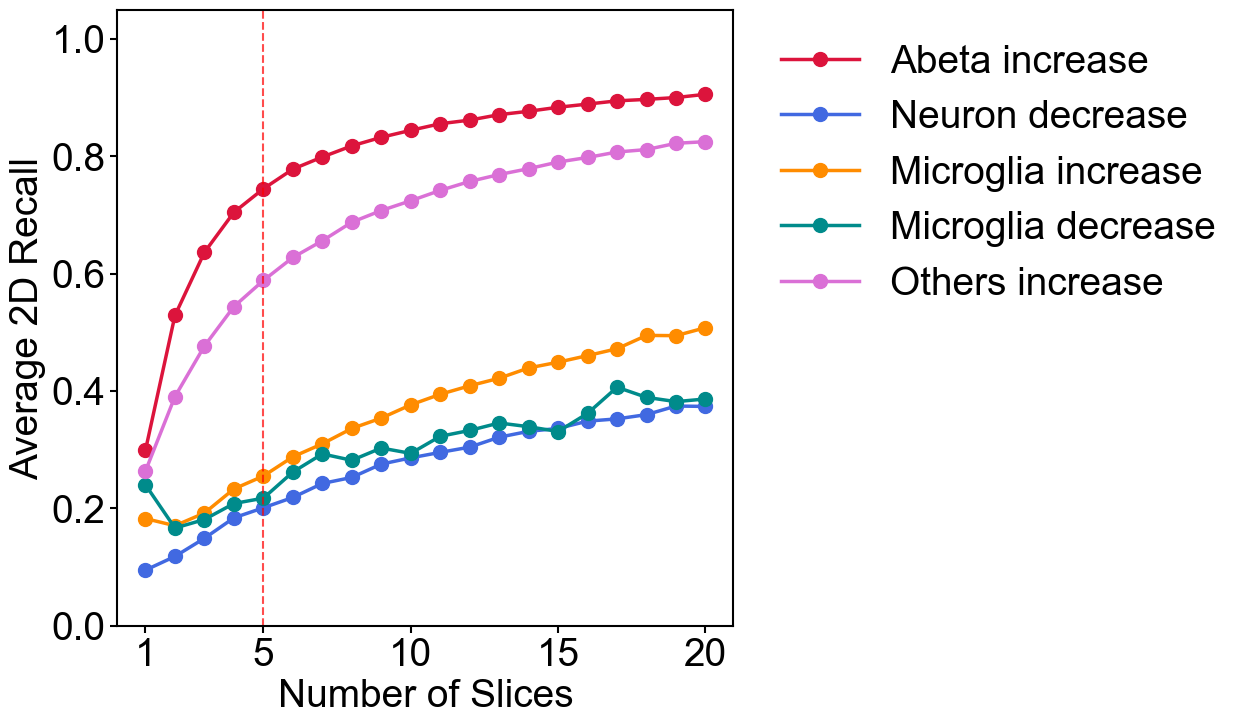

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import concurrent.futures
import os
from datetime import datetime

#
def process_slice(args):
    """
    1 100 Recall 
     Recall 
    """
    #
    condition_name, params, slice_num, ground_truth_regions = args
    file_tag = params['file_tag']
    
    #
    if not ground_truth_regions:
        return (condition_name, slice_num, np.nan)
        
    total_positives = len(ground_truth_regions)
    recalls_for_current_slice = []

    #
    for t in range(100):
        #
        filepath = f'/export3/Imaging/ds4_Data4/Neurology_project_data_archive/Region/WT_9m_vs_APP_9m_raw_value_regions_glm_ver_{file_tag}_random_slice_{slice_num}_trial_{t}.csv'
        
        try:
            #
            predicted_df = pd.read_csv(filepath, index_col='atlasID')
            predicted_regions = set(predicted_df.index)
        except FileNotFoundError:
            continue #  

        #
        #
        true_positives = len(ground_truth_regions.intersection(predicted_regions))
        
        #
        recall = true_positives / total_positives
        recalls_for_current_slice.append(recall)

    if recalls_for_current_slice:
        avg_recall = np.mean(recalls_for_current_slice)
        return (condition_name, slice_num, avg_recall)
    else:
        #
        return (condition_name, slice_num, np.nan)

#
def main(conditions):
    """ Recall """
    
    #
    ground_truths = {}
    print("Loading ground truth files...")
    for condition_name, params in conditions.items():
        file_tag = params['file_tag']
        #
        gt_filepath = f'/export3/Imaging/ds4_Data4/Neurology_project_data_archive/Region/WT_9m_vs_APP_9m_raw_value_regions_{file_tag}.csv'
        try:
            gt_df = pd.read_csv(gt_filepath, index_col='atlasID')
            #
            ground_truths[condition_name] = set(gt_df.index)
            print(f" -> Found {len(ground_truths[condition_name])} regions for '{condition_name}'")
        except FileNotFoundError:
            print(f" -> WARNING: Ground truth file not found for '{condition_name}'. Skipping.")
            ground_truths[condition_name] = set() #  

    #
    slice_numbers = range(1, 21)
    tasks = []
    for condition_name, params in conditions.items():
        #
        if ground_truths[condition_name]:
            for slice_num in slice_numbers:
                tasks.append((condition_name, params, slice_num, ground_truths[condition_name]))
    
    #
    results_dict = {name: [np.nan] * len(slice_numbers) for name in conditions.keys()}
    print(f"\n[{datetime.now().strftime('%H:%M:%S')}] Starting parallel processing for {len(tasks)} tasks...")
    with concurrent.futures.ProcessPoolExecutor(max_workers=5) as executor:
        future_to_task = {}
        for task in tasks:
            future = executor.submit(process_slice, task)
            task_info = f"{task[0]} - Slice {task[2]}"
            future_to_task[future] = task_info
        for future in concurrent.futures.as_completed(future_to_task):
            task_info = future_to_task[future]
            try:
                res_condition, res_slice, res_recall = future.result()
                results_dict[res_condition][res_slice - 1] = res_recall
                print(f"[{datetime.now().strftime('%H:%M:%S')}] Finished: {task_info}, Avg Recall: {res_recall:.4f}")
            except Exception as exc:
                print(f"[{datetime.now().strftime('%H:%M:%S')}] ERROR: {task_info} generated an exception: {exc}")
    print(f"[{datetime.now().strftime('%H:%M:%S')}] All processing finished!")
    return results_dict

#
if __name__ == "__main__":
    #
    conditions_to_run = {
        'Abeta increase':    {'file_tag': 'Abeta_increase', 'color': 'crimson'},
        'Neuron decrease':    {'file_tag': 'NeuN_decrease', 'color': 'royalblue'},
        'Microglia increase': {'file_tag': 'Iba1_increase', 'color': 'darkorange'},
        'Microglia decrease': {'file_tag': 'Iba1_decrease', 'color': 'darkcyan'},
        'Others increase':    {'file_tag': 'others_increase', 'color': 'orchid'}
    }


    #
    #
    new_results = main(conditions_to_run)
    #
    #
    results_df = pd.DataFrame(new_results)
    
    #
    slice_numbers = range(1, 21)
    results_df['Number of Slices'] = slice_numbers
    
    #
    cols = ['Number of Slices'] + [col for col in results_df.columns if col != 'Number of Slices']
    results_df = results_df[cols]

    #
    output_csv_path = '/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/Combined_recall_vs_slice_number_data_WT_9m_vs_APP_9m.csv'
    results_df.to_csv(output_csv_path, index=False)
    print(f"\nPlotting data saved to: {output_csv_path}")
    # ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
    #
    print("\nPlotting results...")
    slice_numbers = range(1, 21)
    plt.style.use('default')
    matplotlib.rcParams['pdf.use14corefonts'] = True
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(12, 8))

    #
    #
    for condition_name, recalls in new_results.items():
        if not np.isnan(recalls).all():
            ax.plot(slice_numbers, recalls,
                    marker='o', markersize=10, linestyle='-', linewidth=2.5,
                    color=conditions_to_run[condition_name]['color'], 
                    label=condition_name)
                    
    ax.axvline(x=5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_xlabel('Number of Slices', fontsize=28)
    ax.set_ylabel('Average 2D Recall', fontsize=28)
    ax.set_xticks([1, 5, 10, 15, 20])
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.tick_params(direction='out', width=1.5, length=5)
    ax.set_aspect(aspect=(ax.get_xlim()[1]-ax.get_xlim()[0])/(ax.get_ylim()[1]-ax.get_ylim()[0]), adjustable='box')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=28, frameon=False)
    plt.savefig('/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/Combined_recall_vs_slice_number_parallel_WT_9m_vs_APP_9m.pdf',
                transparent=True, dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()

In [5]:
import pandas as pd

csv_path = '/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/Combined_recall_vs_slice_number_data_WT_9m_vs_APP_9m.csv'

results_df = pd.read_csv(csv_path)

row = results_df[results_df['Number of Slices'] == 5].iloc[0]

print("\n--- Values at Slice Number = 5 ---")
for condition, value in row.items():
    if condition != 'Number of Slices':
        print(f"  {condition:25s}: {value:.4f}")



--- Values at Slice Number = 5 ---
  Abeta increase           : 0.7446
  Neuron decrease          : 0.2009
  Microglia increase       : 0.2550
  Microglia decrease       : 0.2173
  Others increase          : 0.5884


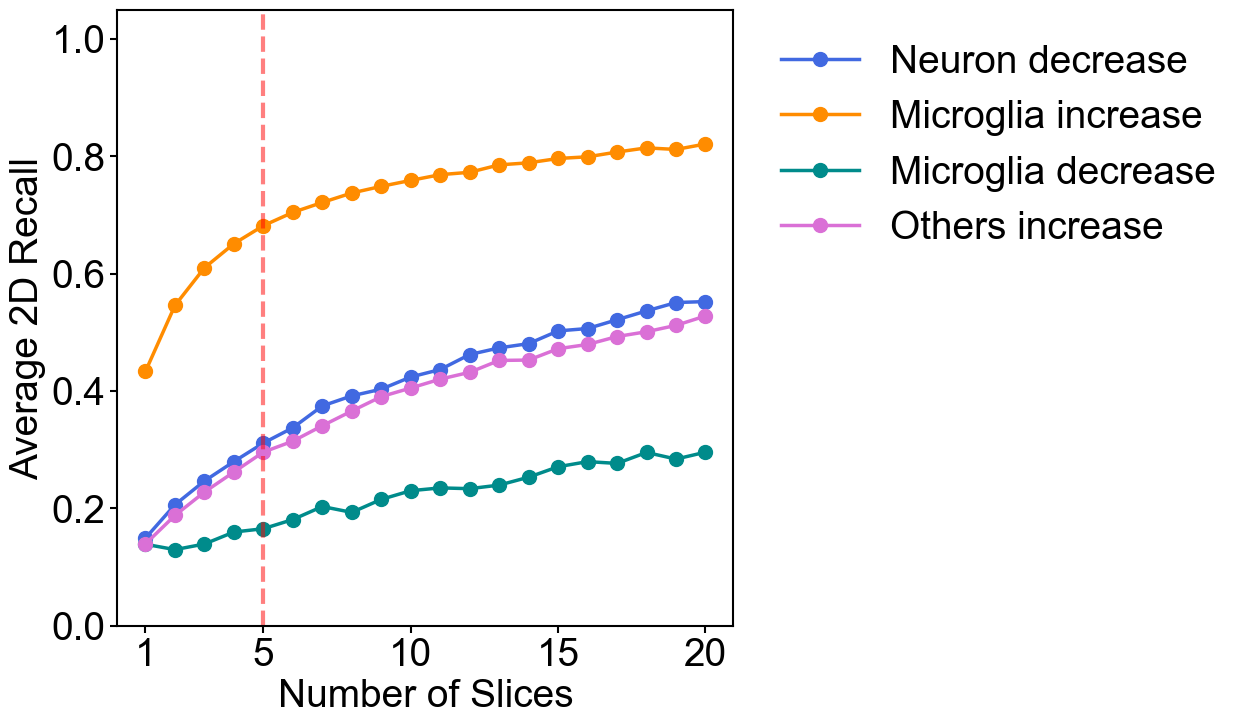

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import concurrent.futures
import os
from datetime import datetime

#
def process_slice(args):
    """
    1 100 Recall 
     Recall 
    """
    #
    condition_name, params, slice_num, ground_truth_regions = args
    file_tag = params['file_tag']
    
    #
    if not ground_truth_regions:
        return (condition_name, slice_num, np.nan)
        
    total_positives = len(ground_truth_regions)
    recalls_for_current_slice = []

    #
    for t in range(100):
        #
        filepath = f'/export3/Imaging/ds4_Data4/Neurology_project_data_archive/Region/VCP_WT_vs_mut_raw_value_regions_glm_ver_{file_tag}_random_slice_{slice_num}_trial_{t}.csv'
        
        try:
            #
            predicted_df = pd.read_csv(filepath, index_col='atlasID')
            predicted_regions = set(predicted_df.index)
        except FileNotFoundError:
            continue #  

        #
        #
        true_positives = len(ground_truth_regions.intersection(predicted_regions))
        
        #
        recall = true_positives / total_positives
        recalls_for_current_slice.append(recall)

    if recalls_for_current_slice:
        avg_recall = np.mean(recalls_for_current_slice)
        return (condition_name, slice_num, avg_recall)
    else:
        #
        return (condition_name, slice_num, np.nan)

#
def main(conditions):
    """ Recall """
    
    #
    ground_truths = {}
    print("Loading ground truth files...")
    for condition_name, params in conditions.items():
        file_tag = params['file_tag']
        #
        gt_filepath = f'/export3/Imaging/ds4_Data4/Neurology_project_data_archive/Region/VCP_WT_vs_mut_raw_value_regions_{file_tag}.csv'
        try:
            gt_df = pd.read_csv(gt_filepath, index_col='atlasID')
            #
            ground_truths[condition_name] = set(gt_df.index)
            print(f" -> Found {len(ground_truths[condition_name])} regions for '{condition_name}'")
        except FileNotFoundError:
            print(f" -> WARNING: Ground truth file not found for '{condition_name}'. Skipping.")
            ground_truths[condition_name] = set() #  

    #
    slice_numbers = range(1, 21)
    tasks = []
    for condition_name, params in conditions.items():
        #
        if ground_truths[condition_name]:
            for slice_num in slice_numbers:
                tasks.append((condition_name, params, slice_num, ground_truths[condition_name]))
    
    #
    results_dict = {name: [np.nan] * len(slice_numbers) for name in conditions.keys()}
    print(f"\n[{datetime.now().strftime('%H:%M:%S')}] Starting parallel processing for {len(tasks)} tasks...")
    with concurrent.futures.ProcessPoolExecutor(max_workers=5) as executor:
        future_to_task = {}
        for task in tasks:
            future = executor.submit(process_slice, task)
            task_info = f"{task[0]} - Slice {task[2]}"
            future_to_task[future] = task_info
        for future in concurrent.futures.as_completed(future_to_task):
            task_info = future_to_task[future]
            try:
                res_condition, res_slice, res_recall = future.result()
                results_dict[res_condition][res_slice - 1] = res_recall
                print(f"[{datetime.now().strftime('%H:%M:%S')}] Finished: {task_info}, Avg Recall: {res_recall:.4f}")
            except Exception as exc:
                print(f"[{datetime.now().strftime('%H:%M:%S')}] ERROR: {task_info} generated an exception: {exc}")
    print(f"[{datetime.now().strftime('%H:%M:%S')}] All processing finished!")
    return results_dict

#
if __name__ == "__main__":
    #
    conditions_to_run = {
        'Neuron decrease':    {'file_tag': 'NeuN_decrease', 'color': 'royalblue'},
        'Microglia increase': {'file_tag': 'Iba1_increase', 'color': 'darkorange'},
        'Microglia decrease': {'file_tag': 'Iba1_decrease', 'color': 'darkcyan'},
        'Others increase':    {'file_tag': 'others_increase', 'color': 'orchid'}
    }


    #
    #
    new_results = main(conditions_to_run)
    
    #
    #
    results_df = pd.DataFrame(new_results)
    
    #
    slice_numbers = range(1, 21)
    results_df['Number of Slices'] = slice_numbers
    
    #
    cols = ['Number of Slices'] + [col for col in results_df.columns if col != 'Number of Slices']
    results_df = results_df[cols]

    #
    output_csv_path = '/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/Combined_recall_vs_slice_number_data_VCP_WT_vs_mut.csv'
    results_df.to_csv(output_csv_path, index=False)
    print(f"\nPlotting data saved to: {output_csv_path}")
    # ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

    #
    print("\nPlotting results...")
    slice_numbers = range(1, 21)
    plt.style.use('default')
    matplotlib.rcParams['pdf.use14corefonts'] = True
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(12, 8))

    #
    #
    for condition_name, recalls in new_results.items():
        if not np.isnan(recalls).all():
            ax.plot(slice_numbers, recalls,
                    marker='o', markersize=10, linestyle='-', linewidth=2.5,
                    color=conditions_to_run[condition_name]['color'], 
                    label=condition_name)
                    
    ax.axvline(x=5, color='red', linestyle='--', linewidth=3, alpha=0.5)
    ax.set_xlabel('Number of Slices', fontsize=28)
    ax.set_ylabel('Average 2D Recall', fontsize=28)
    ax.set_xticks([1, 5, 10, 15, 20])
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.tick_params(direction='out', width=1.5, length=5)
    ax.set_aspect(aspect=(ax.get_xlim()[1]-ax.get_xlim()[0])/(ax.get_ylim()[1]-ax.get_ylim()[0]), adjustable='box')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=28, frameon=False)
    plt.savefig('/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/Combined_recall_vs_slice_number_parallel_VCP_WT_vs_mut.pdf',
                transparent=True, dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()

In [7]:
import pandas as pd

csv_path = '/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/Combined_recall_vs_slice_number_data_VCP_WT_vs_mut.csv'

results_df = pd.read_csv(csv_path)

row = results_df[results_df['Number of Slices'] == 5].iloc[0]

print("\n--- Values at Slice Number = 5 ---")
for condition, value in row.items():
    if condition != 'Number of Slices':
        print(f"  {condition:25s}: {value:.4f}")



--- Values at Slice Number = 5 ---
  Neuron decrease          : 0.3112
  Microglia increase       : 0.6818
  Microglia decrease       : 0.1652
  Others increase          : 0.2958


## Recall vs section interval (Protocol 2): App and VCP

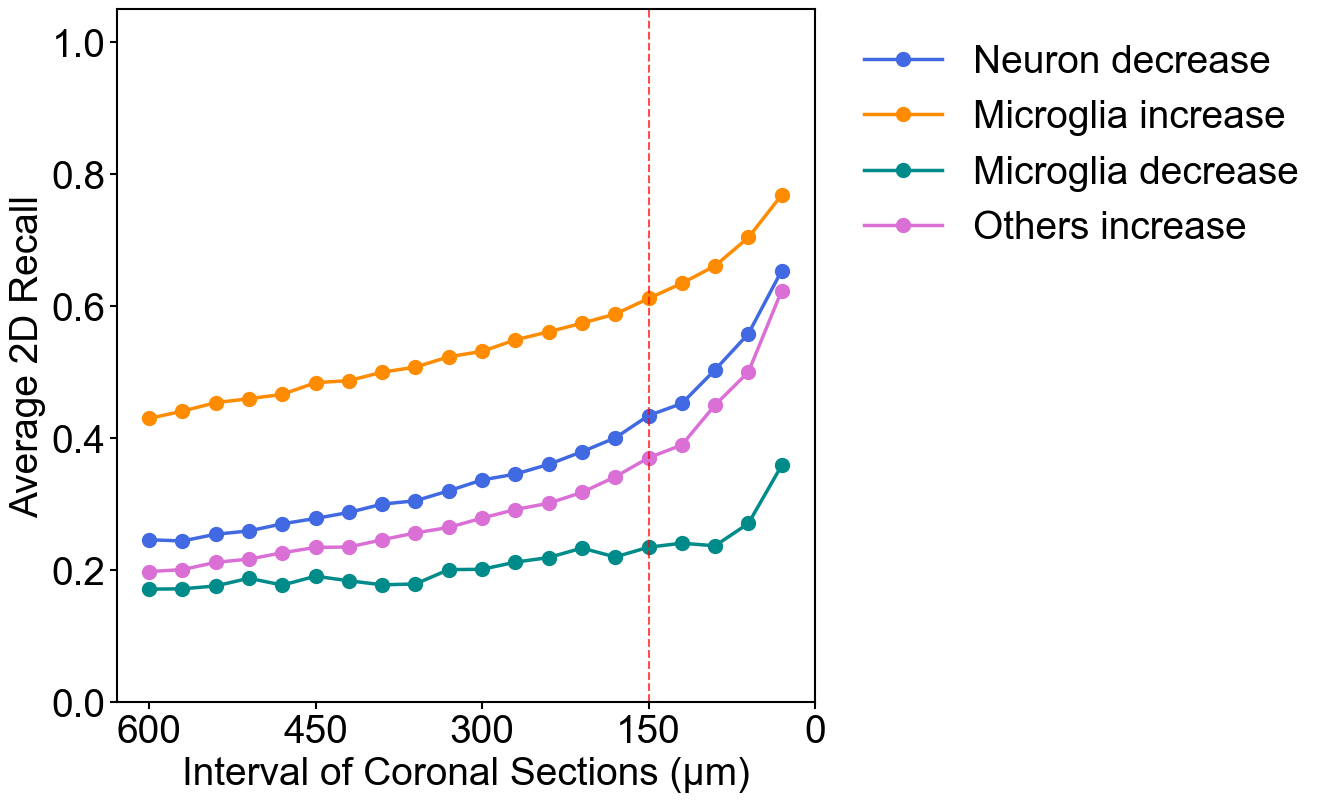

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

#

#
csv_path = '/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/Recall_vs_SamplingSpan_Stereology_Summary.csv'

#
color_map = {
    'Abeta increase': 'darkorange',
    'Neuron decrease': 'royalblue',
    'Microglia increase': 'darkorange',
    'Microglia decrease': 'darkcyan',
    'Others increase': 'orchid'
}

#
pdf_output_path = '/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/Recall_vs_SamplingSpan_Stereology_InvertedX_VCP_WT_vs_mut.pdf'


#
print(f"Loading data from: {csv_path}")
results_df = pd.read_csv(csv_path, index_col=0)

print("Plotting results with inverted X-axis...")

#
plt.style.use('default')
matplotlib.rcParams['pdf.use14corefonts'] = True
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.5

fig, ax = plt.subplots(figsize=(9, 9))

#
for condition_name in results_df.columns:
    if condition_name in color_map:
        ax.plot(results_df.index, results_df[condition_name],
                marker='o', markersize=10, linestyle='-', linewidth=2.5,
                color=color_map[condition_name],  
                label=condition_name)

#
ax.axvline(x=150, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

#
ax.set_xlabel('Interval of Coronal Sections (μm)', fontsize=28)
ax.set_ylabel('Average 2D Recall', fontsize=28)
ax.set_xticks([0, 150, 300, 450, 600])
ax.set_ylim(0, 1.05)
ax.tick_params(axis='both', which='major', labelsize=28)
ax.tick_params(direction='out', width=1.5, length=5)

#
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=28, frameon=False)

# ★★★★★★★★★★★★★★★★★★★★★★★
#
ax.invert_xaxis()
# ★★★★★★★★★★★★★★★★★★★★★★★

#
plt.savefig(pdf_output_path, transparent=True, dpi=300, bbox_inches='tight', pad_inches=0.1)
print(f"\nGraph saved to: {pdf_output_path}")
plt.show()

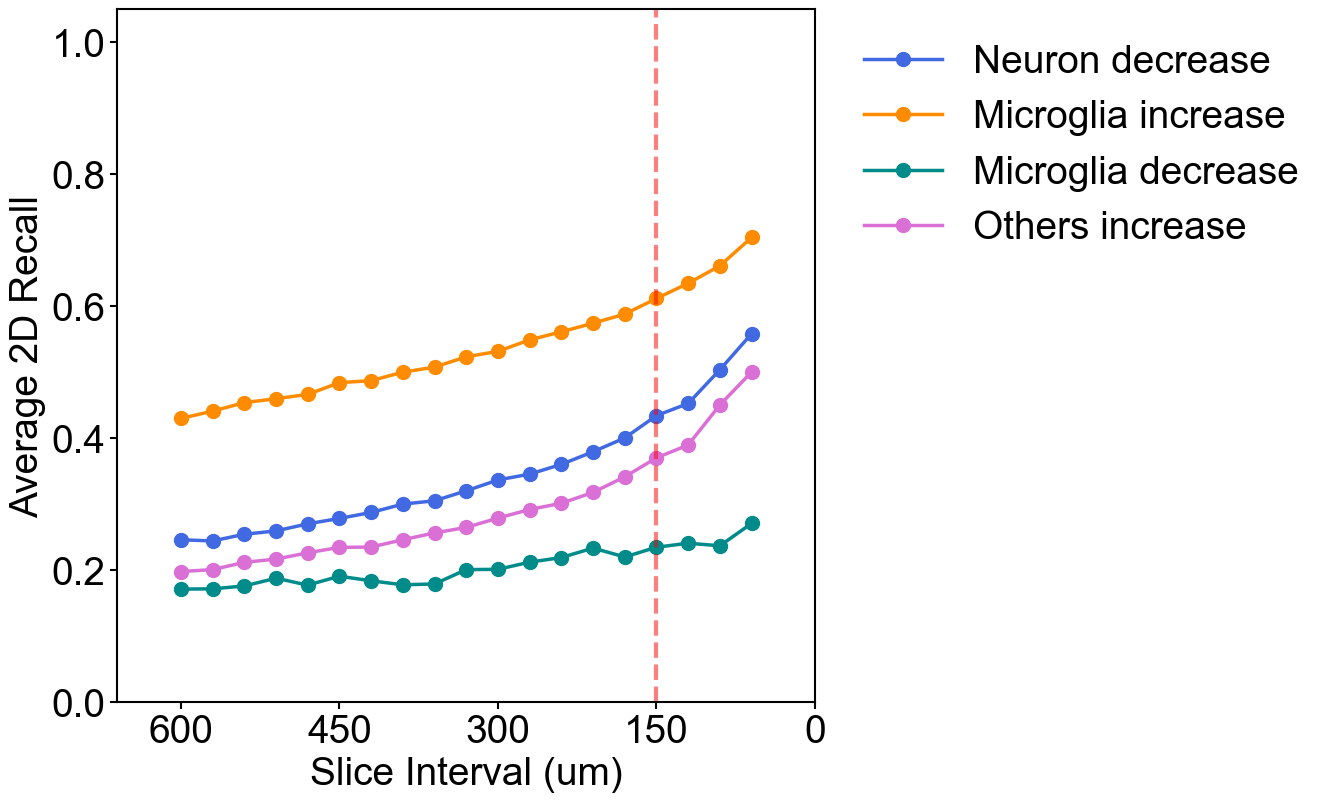

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

#

#
csv_path = '/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/Recall_vs_SamplingSpan_Stereology_Summary.csv'

#
color_map = {
    'Abeta increase': 'darkorange',
    'Neuron decrease': 'royalblue',
    'Microglia increase': 'darkorange',
    'Microglia decrease': 'darkcyan',
    'Others increase': 'orchid'
}

#
pdf_output_path = '/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/Recall_vs_SamplingSpan_Stereology_InvertedX_VCP_WT_vs_mut.pdf'


#
print(f"Loading data from: {csv_path}")
results_df = pd.read_csv(csv_path, index_col=0)

#
plot_df = results_df[results_df.index >= 60]


print("Plotting results with inverted X-axis...")

#
plt.style.use('default')
matplotlib.rcParams['pdf.use14corefonts'] = True
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.5

fig, ax = plt.subplots(figsize=(9, 9))

#
for condition_name in plot_df.columns:
    #if condition_name == 'Microglia decrease':
    #    continue

    if condition_name in color_map:
        ax.plot(plot_df.index, plot_df[condition_name],
                marker='o', markersize=10, linestyle='-', linewidth=2.5,
                color=color_map[condition_name],  
                label=condition_name)

#
ax.axvline(x=150, color='red', linestyle='--', linewidth=3, alpha=0.5)
#ax.axvline(x=60, color='purple', linestyle='--', linewidth=3, alpha=0.5)

#
ax.set_xlabel('Slice Interval (um)', fontsize=28)
ax.set_ylabel('Average 2D Recall', fontsize=28)
#
ax.set_xticks([600, 450, 300, 150, 0]) # X 
# ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
ax.set_ylim(0, 1.05)
ax.tick_params(axis='both', which='major', labelsize=28)
ax.tick_params(direction='out', width=1.5, length=5)

#
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=28, frameon=False)

#
ax.set_xlim(660, 0)

#
plt.savefig(pdf_output_path, transparent=True, dpi=300, bbox_inches='tight', pad_inches=0.1)
print(f"\nGraph saved to: {pdf_output_path}")
plt.show()

In [10]:
import pandas as pd
import numpy as np

csv_path = '/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/Recall_vs_SamplingSpan_Stereology_Summary.csv'

results_df = pd.read_csv(csv_path, index_col=0)

print("\n--- Values at Span = 150 µm ---")
if 150 in results_df.index:
    row = results_df.loc[150]
    for condition, value in row.items():
        print(f"  {condition:25s}: {value:.4f}")
else:
    for col in results_df.columns:
        interp_val = np.interp(150, results_df.index.values, results_df[col].values)
        print(f"  {col:25s}: {interp_val:.4f} (interpolated)")



--- Values at Span = 150 µm ---
  Neuron decrease          : 0.4347
  Microglia increase       : 0.6121
  Microglia decrease       : 0.2352
  Others increase          : 0.3707
